# 03. Model Development Lab
**Objective:** Train, tune, and evaluate machine learning models (LightGBM) for alpha generation.

### Institutional Workflow:
1. **Data Integrity:** Robust target construction and categorical encoding.
2. **Feature Engineering:** Sector-neutral normalization and winsorization.
3. **Modeling:** LightGBM with custom objective (Weighted Symmetric MAE).
4. **Evaluation:** Information Coefficient (IC) and Long-Short Cumulative Returns.

In [14]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('../').resolve()
sys.path.append(str(PROJECT_ROOT))

from config.settings import config
from quant_alpha.utils import load_parquet
from quant_alpha.models.lightgbm_model import LightGBMModel
from quant_alpha.models.xgboost_model import XGBoostModel
from quant_alpha.models.catboost_model import CatBoostModel

%matplotlib inline

## 1. Data Prep & Split

In [15]:
# --- Helper Functions (copied from train_models.py for notebook usage) ---
def fit_transform_winsorize(train, test, features, clip_percentile=0.01):
    print(f"[NORM] Winsorizing {len(features)} features (Fit on Train)...")
    for col in features:
        # Fit on Train only to avoid look-ahead bias
        lower = train[col].quantile(clip_percentile)
        upper = train[col].quantile(1.0 - clip_percentile)
        train[col] = train[col].clip(lower, upper)
        test[col] = test[col].clip(lower, upper)
    return train, test

def safe_sector_neutral_normalize(df, features, sector_col='sector'):
    if sector_col not in df.columns:
        print("[NORM] Sector missing. Using per-date normalization...")
        means = df.groupby('date')[features].transform('mean')
        stds  = df.groupby('date')[features].transform('std').replace(0, 1e-8)
        df[features] = (df[features] - means) / (stds + 1e-8)
        return df

    print(f"[NORM] Sector-Neutral Normalization on {len(features)} features...")
    means = df.groupby(['date', sector_col])[features].transform('mean')
    stds  = df.groupby(['date', sector_col])[features].transform('std').replace(0, 1e-8)
    df[features] = (df[features] - means) / (stds + 1e-8)
    return df

def weighted_symmetric_mae(y_true, y_pred):
    # Penalizes wrong-sign predictions 2x
    residuals = y_true - y_pred
    weights   = np.where(y_true * y_pred < 0, 2.0, 1.0)
    grad      = -weights * np.tanh(residuals)
    hess      = np.maximum(weights * (1.0 - np.tanh(residuals) ** 2), 1e-3)
    return grad, hess

df = load_parquet(config.CACHE_DIR / 'master_data_with_factors.parquet')
df['date'] = pd.to_datetime(df['date'])

# FIX: Calculate target if missing
if 'target' not in df.columns:
    print("⚠️ 'target' column missing. Calculating Sector-Neutral Return...")
    if 'raw_ret_5d' not in df.columns:
        if 'open' in df.columns:
            print("⚠️ 'raw_ret_5d' missing. Calculating from Open prices...")
            df = df.sort_values(['ticker', 'date'])
            df['next_open'] = df.groupby('ticker')['open'].shift(-1)
            df['future_open'] = df.groupby('ticker')['open'].shift(-6)
            df['raw_ret_5d'] = (df['future_open'] / df['next_open']) - 1
        else:
            print("❌ 'open' column missing. Cannot calculate returns.")

    if 'raw_ret_5d' in df.columns and 'sector' in df.columns:
        sector_mean = df.groupby(['date', 'sector'], observed=False)['raw_ret_5d'].transform('mean')
        df['target'] = df['raw_ret_5d'] - sector_mean
    elif 'raw_ret_5d' in df.columns:
        df['target'] = df['raw_ret_5d']
    else:
        print("❌ Could not create 'target' column.")

if 'target' in df.columns:
    df = df.dropna(subset=['target'])

# Define Features
exclude = ['date', 'ticker', 'target', 'raw_ret_5d', 'open', 'high', 'low', 'close', 'volume', 'sector', 'industry']
features = [c for c in df.columns if c not in exclude and np.issubdtype(df[c].dtype, np.number)]

# 1. Split FIRST (Avoid Leakage)
split_date = '2022-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

# 2. Preprocessing (Fit on Train, Apply to Test)
train_df, test_df = fit_transform_winsorize(train_df, test_df, features)

# Sector Neutral is cross-sectional (per date), so it's safe to run independently
train_df = safe_sector_neutral_normalize(train_df, features)
test_df = safe_sector_neutral_normalize(test_df, features)

⚠️ 'target' column missing. Calculating Sector-Neutral Return...
Train: 727,046 | Test: 245,979
[NORM] Winsorizing 159 features (Fit on Train)...
[NORM] Sector-Neutral Normalization on 159 features...


C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_21664\2783453492.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(['date', sector_col])[features].transform('mean')
C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_21664\2783453492.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df.groupby(['date', sector_col])[features].transform('std').replace(0, 1e-8)


[NORM] Sector-Neutral Normalization on 159 features...


C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_21664\2783453492.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(['date', sector_col])[features].transform('mean')
C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_21664\2783453492.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df.groupby(['date', sector_col])[features].transform('std').replace(0, 1e-8)


## 2. Train Models (LightGBM, XGBoost, CatBoost)

In [ ]:
models = {}

print("Training LightGBM...")
lgb_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 5,
    'objective': weighted_symmetric_mae,
    'n_jobs': -1,
    'verbose': -1
}
models['LightGBM'] = LightGBMModel(params=lgb_params)
models['LightGBM'].fit(train_df[features], train_df['target'])

print("Training XGBoost...")
xgb_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 5,
    'objective': weighted_symmetric_mae,
    'n_jobs': -1,
    'verbosity': 0
}
models['XGBoost'] = XGBoostModel(params=xgb_params)
models['XGBoost'].fit(train_df[features], train_df['target'])

print("Training CatBoost...")
cat_params = {
    'iterations': 300,
    'learning_rate': 0.05,
    'depth': 5,
    'loss_function': 'MAE',
    'thread_count': -1,
    'verbose': 0,
    'allow_writing_files': False
}
models['CatBoost'] = CatBoostModel(params=cat_params)
models['CatBoost'].fit(train_df[features], train_df['target'])

Training LightGBM...
2026-03-08 18:07:18,654 - INFO - [LightGBM] Trained 727046 rows in 30.50s
Training XGBoost...
2026-03-08 18:07:54,499 - INFO - [XGBoost] Trained 727046 rows in 35.44s
Training CatBoost...
2026-03-08 18:09:44,667 - INFO - [CatBoost] Trained 727046 rows in 109.71s


## 3. Evaluation (OOS IC)

LightGBM OOS Mean IC: 0.0157
LightGBM OOS IC IR:   0.1019
XGBoost OOS Mean IC: 0.0143
XGBoost OOS IC IR:   0.0935
CatBoost OOS Mean IC: -0.0021
CatBoost OOS IC IR:   -0.0262


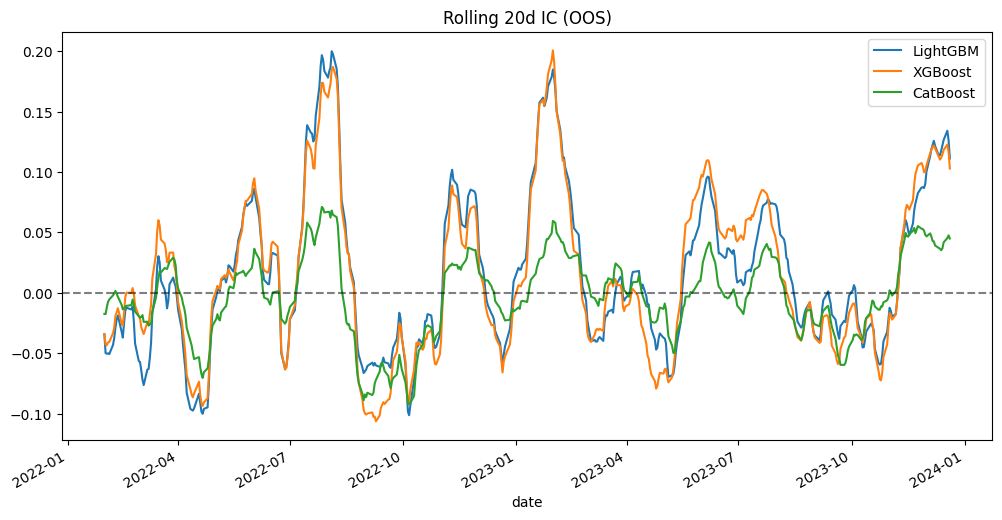

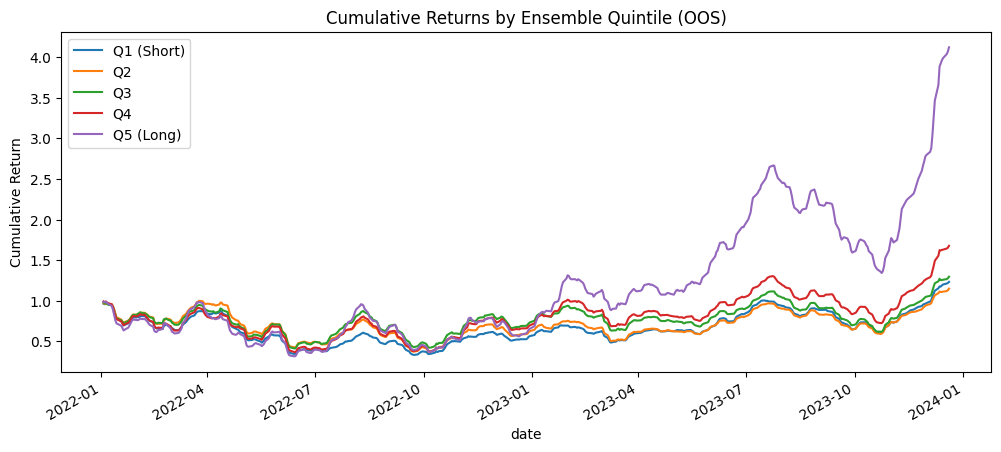

In [ ]:
results = {}
plt.figure(figsize=(12, 6))

for name, model in models.items():
    pred_col = f'pred_{name}'
    test_df[pred_col] = model.predict(test_df[features])
    
    # IC
    ic = test_df.groupby('date')[[pred_col, 'target']].apply(lambda x: x[pred_col].corr(x['target'], method='spearman'))
    results[name] = ic
    
    # Turnover Proxy (Day-to-Day Signal Stability)
    # High turnover (> 0.50) implies high trading costs
    turnover = test_df.groupby('ticker')[pred_col].diff().abs().mean()
    print(f"{name} Signal Turnover: {turnover:.4f}")
    print(f"{name} OOS Mean IC: {ic.mean():.4f}")
    print(f"{name} OOS IC IR:   {ic.mean() / ic.std():.4f}")
    
    ic.rolling(20).mean().plot(label=name)

plt.title('Rolling 20d IC (OOS)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Cumulative Returns (Ensemble)
test_df['pred_ensemble'] = test_df[[f'pred_{n}' for n in models]].mean(axis=1)
test_df['quantile'] = test_df.groupby('date')['pred_ensemble'].transform(lambda x: pd.qcut(x, 5, labels=False))
q_ret = test_df.groupby(['date', 'quantile'])['raw_ret_5d'].mean().unstack()

plt.figure(figsize=(12, 5))
(1 + q_ret).cumprod().plot(ax=plt.gca())
plt.title('Cumulative Returns by Ensemble Quintile (OOS)')
plt.ylabel('Cumulative Return')
plt.legend(['Q1 (Short)', 'Q2', 'Q3', 'Q4', 'Q5 (Long)'])
plt.show()

## 4. Feature Importance

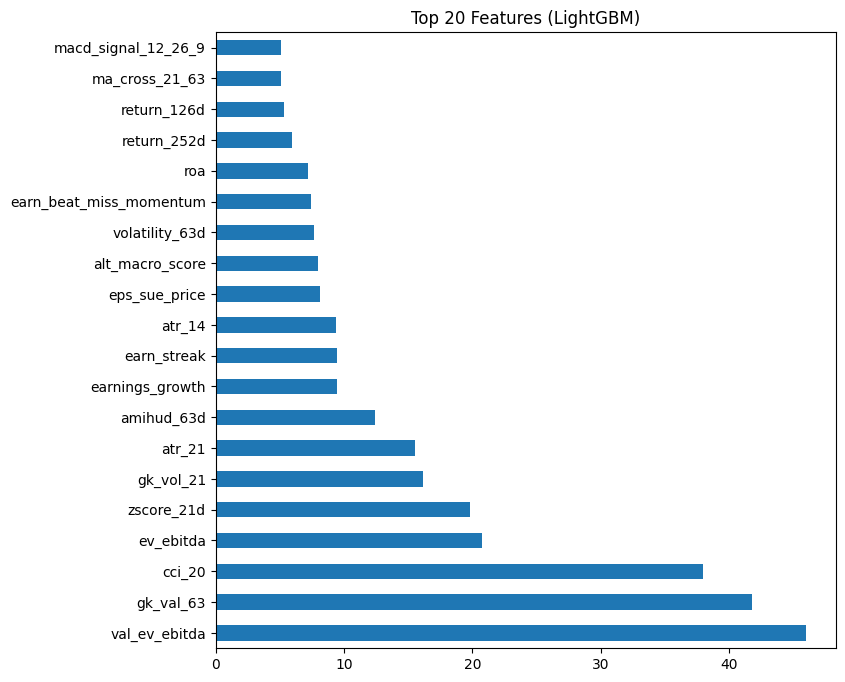

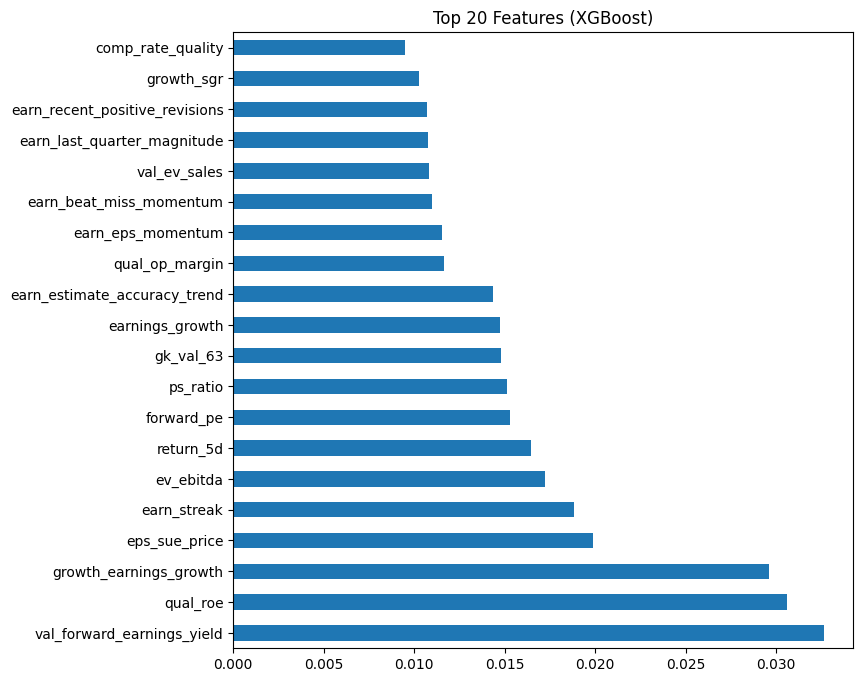

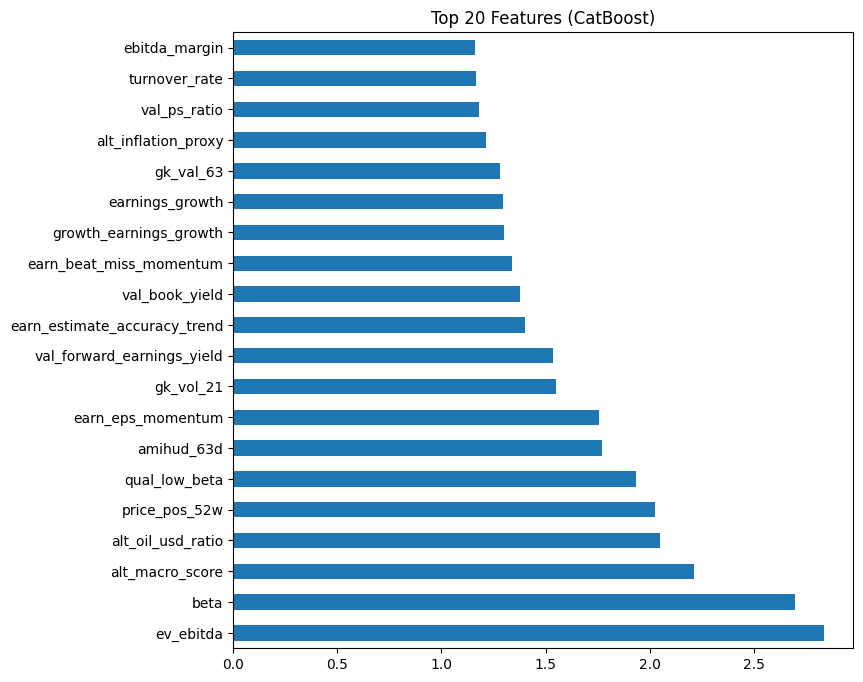

In [13]:
for name, model in models.items():
    plt.figure(figsize=(8, 8))
    imp = model.feature_importance.sort_values(ascending=False).head(20)
    imp.plot(kind='barh', title=f'Top 20 Features ({name})')
    plt.show()
   